(python_by_example)=
```{raw} jupyter
<div id="qe-notebook-header" align="right" style="text-align:right;">
        <a href="https://quantecon.org/" title="quantecon.org">
                <img style="width:250px;display:inline;" width="250px" src="https://assets.quantecon.org/img/qe-menubar-logo.svg" alt="QuantEcon">
        </a>
</div>
```

# An Introductory Example

```{index} single: Python; Introductory Example
```

## Overview

നമ്മൾ ഇപ്പോൾ Python language തന്നെ പഠിച്ചു തുടങ്ങാൻ തയ്യാറാണ്.

ഈ lecture-ൽ, നമ്മൾ ചെറിയ Python programs എഴുതി, അവയെ വിശദമായി പരിശോധിക്കും.

ഇതിന്റെ ലക്ഷ്യം നിങ്ങൾക്ക് അടിസ്ഥാന Python syntax-ഉം data structures-ഉം പരിചയപ്പെടുത്തുക എന്നതാണ്.

കൂടുതൽ ആഴത്തിലുള്ള concepts പിന്നീടുള്ള lectures-ൽ കൈകാര്യം ചെയ്യും.

ഇത് തുടങ്ങുന്നതിന് മുമ്പ് Python-ൽ getting started ചെയ്യുന്നതിനെക്കുറിച്ചുള്ള {doc}`lecture <getting_started>` നിങ്ങൾ വായിച്ചിരിക്കണം.


## The Task: Plotting a White Noise Process

ഓരോ draw $\epsilon_t$-ഉം independent standard normal ആയ white noise
process $\epsilon_0, \epsilon_1, \ldots, \epsilon_T$ simulate ചെയ്ത് plot ചെയ്യണം എന്ന് കരുതുക.

മറ്റൊരു വിധത്തിൽ പറഞ്ഞാൽ, ഇതുപോലുള്ള figures generate ചെയ്യണം:

```{figure} /_static/lecture_specific/python_by_example/test_program_1_updated.png
:scale: 120
```

(ഇവിടെ $t$ horizontal axis-ലും $\epsilon_t$ vertical axis-ലും ആണ്.)

നമ്മൾ ഇത് പല വ്യത്യസ്ത രീതികളിൽ ചെയ്യും, ഓരോ തവണയും Python-നെക്കുറിച്ച് കൂടുതൽ കാര്യങ്ങൾ പഠിക്കും.

## Version 1

(ourfirstprog)=
നമ്മൾ set ചെയ്ത task ചെയ്യുന്ന കുറച്ച് lines of code ഇവിടെ ഉണ്ട്

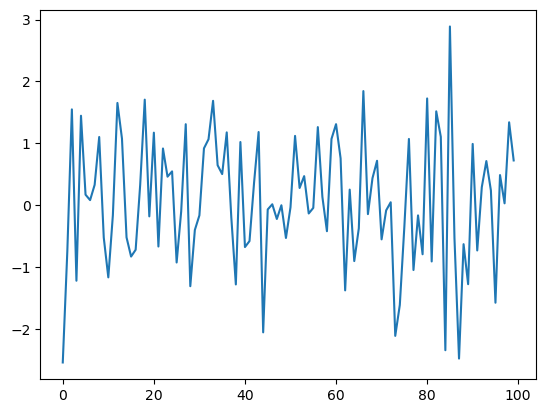

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng()
ϵ_values = rng.standard_normal(100)
plt.plot(ϵ_values)
plt.show()

ഈ program-നെ ഭാഗങ്ങളാക്കി, അത് എങ്ങനെ പ്രവർത്തിക്കുന്നു എന്ന് നോക്കാം.

(import)=
### Imports

Program-ന്റെ ആദ്യ രണ്ട് lines external code
libraries-ൽ നിന്ന് functionality import ചെയ്യുന്നു.

ആദ്യ line {doc}`NumPy <numpy>` import ചെയ്യുന്നു, ഇത് ഇത്തരം tasks-ക്ക് ഇഷ്ടപ്പെട്ട ഒരു Python package ആണ്

* arrays (vectors and matrices) കൈകാര്യം ചെയ്യൽ
* `cos`, `sqrt` പോലുള്ള common mathematical functions
* random numbers generate ചെയ്യൽ
* linear algebra, etc.

`import numpy as np` എന്ന് ചെയ്ത ശേഷം, `np.attribute` എന്ന syntax വഴി ഈ attributes-ലേക്ക് നമുക്ക് access ലഭിക്കും.

ഇവിടെ രണ്ട് examples കൂടി

In [2]:
np.sqrt(4)

np.float64(2.0)

In [3]:
np.log(4)

np.float64(1.3862943611198906)

#### Why So Many Imports?

Python programs സാധാരണയായി multiple import statements ആവശ്യപ്പെടുന്നു.

കാരണം, core language മനഃപൂർവ്വം ചെറുതായി നിലനിർത്തിയിരിക്കുന്നു, അതുകൊണ്ട് അത് പഠിക്കാനും maintain ചെയ്യാനും improve ചെയ്യാനും easy ആണ്.

Python ഉപയോഗിച്ച് interesting ആയ എന്തെങ്കിലും ചെയ്യണമെങ്കിൽ, മിക്കവാറും എപ്പോഴും additional functionality import ചെയ്യേണ്ടി വരും.


#### Packages

```{index} single: Python; Packages
```

മുകളിൽ പറഞ്ഞതുപോലെ, NumPy ഒരു Python package ആണ്.

Developers അവർ share ചെയ്യാൻ ഉദ്ദേശിക്കുന്ന code organize ചെയ്യാൻ packages ഉപയോഗിക്കുന്നു.

വാസ്തവത്തിൽ, ഒരു **package** എന്നത് ഇവ അടങ്ങിയ ഒരു directory മാത്രമാണ്

1. Python code ഉള്ള files --- Python-ന്റെ ഭാഷയിൽ **modules** എന്ന് വിളിക്കുന്നു
1. Python access ചെയ്യാൻ കഴിയുന്ന compiled code ചിലപ്പോൾ (ഉദാ: C അല്ലെങ്കിൽ FORTRAN code-യിൽ നിന്ന് compile ചെയ്ത functions)
1. `import package_name` എന്ന് type ചെയ്യുമ്പോൾ എന്ത് execute ചെയ്യണം എന്ന് specify ചെയ്യുന്ന `__init__.py` എന്ന file

NumPy-യുടെ `__init__.py`-യുടെ location Python-ൽ ഈ code run ചെയ്ത് check ചെയ്യാം:

```{code-block} ipython
:class: no-execute

import numpy as np

print(np.__file__)
```

#### Subpackages

```{index} single: Python; Subpackages
```

`rng = np.random.default_rng()` എന്ന line നോക്കുക.

ഇവിടെ `np` എന്നത് NumPy package-നെ സൂചിപ്പിക്കുന്നു, `random` എന്നത് NumPy-യുടെ ഒരു **subpackage** ആണ്.

Subpackages എന്നത് മറ്റൊരു package-ന്റെ subdirectories ആയ packages മാത്രമാണ്.

ഉദാഹരണത്തിന്, NumPy-യുടെ directory-യുടെ കീഴിൽ `random` എന്ന folder നിങ്ങൾക്ക് കണ്ടെത്താം.

### Importing Names Directly

മുകളിൽ കണ്ട ഈ code ഓർക്കുക

In [4]:
import numpy as np

np.sqrt(4)

np.float64(2.0)

NumPy-യുടെ square root function access ചെയ്യാൻ മറ്റൊരു വഴി ഇവിടെ

In [5]:
from numpy import sqrt

sqrt(4)

np.float64(2.0)

ഇതും correct ആണ്.

നമ്മുടെ code-ൽ `sqrt` പലപ്പോഴും ഉപയോഗിക്കുകയാണെങ്കിൽ, ഇത് ഉപയോഗിക്കുന്നത് typing കുറയ്ക്കും എന്നതാണ് advantage.

ദോഷം, ഒരു long program-ൽ, ഈ രണ്ട് lines പലപ്പോഴും പല മറ്റ് lines-ഉം കൊണ്ട് separate ചെയ്യപ്പെട്ടേക്കാം.

അപ്പോൾ, `sqrt` എവിടെ നിന്ന് വന്നു എന്ന് readers അറിയാൻ ആഗ്രഹിച്ചാൽ, അത് കണ്ടെത്താൻ കൂടുതൽ ബുദ്ധിമുട്ടാകും.

### Random Draws

White noise plot ചെയ്യുന്ന നമ്മുടെ program-ലേക്ക് തിരികെ വരാം, import statements കഴിഞ്ഞുള്ള ബാക്കി മൂന്ന് lines ഇവയാണ്

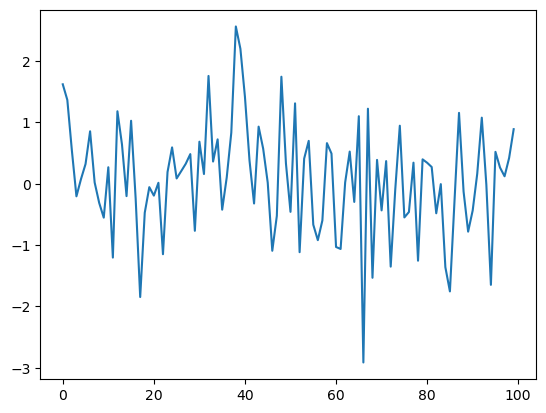

In [6]:
ϵ_values = rng.standard_normal(100)
plt.plot(ϵ_values)
plt.show()

ആദ്യ line 100 (quasi) independent standard normals generate ചെയ്ത്
`ϵ_values`-ൽ store ചെയ്യുന്നു.

അടുത്ത രണ്ട് lines plot generate ചെയ്യുന്നു.

താഴെ ഈ plot configure ചെയ്യാനും improve ചെയ്യാനുമുള്ള പല വഴികളും നമുക്ക് നോക്കാം.

## Alternative Implementations

Standard normal distribution-ൽ നിന്നുള്ള IID draws plot ചെയ്ത {ref}`നമ്മുടെ ആദ്യ program <ourfirstprog>`-ന്റെ ചില alternative versions എഴുതി നോക്കാം.

താഴെയുള്ള programs original-നേക്കാൾ less efficient ആണ്, അതുകൊണ്ട്
ഇവ അല്പം artificial ആണ്.

എന്നാൽ ഇവ ഒരു familiar setting-ൽ ചില പ്രധാന Python syntax-ഉം semantics-ഉം illustrate ചെയ്യാൻ സഹായിക്കുന്നു.

### A Version with a For Loop

`for` loops-ഉം Python lists-ഉം illustrate ചെയ്യുന്ന ഒരു version ഇവിടെ.

(firstloopprog)=

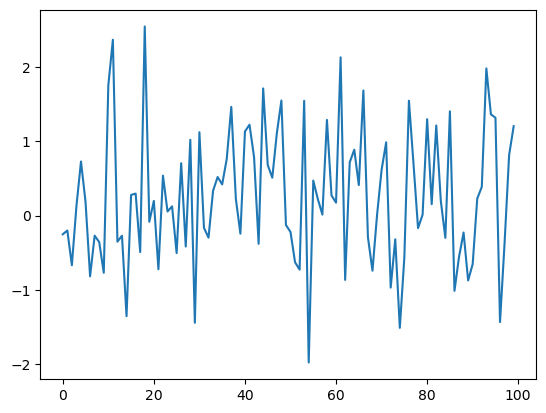

In [7]:
ts_length = 100
ϵ_values = []   # empty list

for i in range(ts_length):
    e = rng.standard_normal()
    ϵ_values.append(e)

plt.plot(ϵ_values)
plt.show()

ചുരുക്കത്തിൽ,

* ആദ്യ line time series-ന്റെ ആവശ്യമുള്ള length set ചെയ്യുന്നു.
* അടുത്ത line, ജനറേറ്റ് ചെയ്യുന്ന $\epsilon_t$ values store ചെയ്യാൻ `ϵ_values` എന്ന empty *list* create ചെയ്യുന്നു.
* `# empty list` എന്ന statement ഒരു *comment* ആണ്, Python-ന്റെ interpreter ഇത് ignore ചെയ്യും.
* അടുത്ത മൂന്ന് lines `for` loop ആണ്, ഇത് ആവർത്തിച്ച് പുതിയ random number $\epsilon_t$ draw ചെയ്ത് `ϵ_values` list-ന്റെ അവസാനത്തിൽ append ചെയ്യുന്നു.
* അവസാന രണ്ട് lines plot generate ചെയ്ത് user-ന് display ചെയ്യുന്നു.

ഈ program-ന്റെ ചില ഭാഗങ്ങൾ കൂടുതൽ വിശദമായി പഠിക്കാം.

(lists_ref)=
### Lists

```{index} single: Python; Lists
```

`ϵ_values = []` എന്ന statement നോക്കുക, ഇത് ഒരു empty list create ചെയ്യുന്നു.

Lists എന്നത് objects-ന്റെ ഒരു collection group ചെയ്യാൻ ഉപയോഗിക്കുന്ന native Python data structure ആണ്.

Lists-ലെ items ordered ആണ്, കൂടാതെ lists-ൽ duplicates അനുവദനീയമാണ്.

ഉദാഹരണത്തിന്, ഇത് try ചെയ്യുക

In [8]:
x = [10, 'foo', False]
type(x)

list

`x`-ന്റെ ആദ്യ element ഒരു [integer](https://en.wikipedia.org/wiki/Integer_(computer_science)) ആണ്, അടുത്തത് ഒരു [string](https://en.wikipedia.org/wiki/String_(computer_science)) ആണ്, മൂന്നാമത്തേത് ഒരു [Boolean value](https://en.wikipedia.org/wiki/Boolean_data_type) ആണ്.

ഒരു list-ലേക്ക് value add ചെയ്യുമ്പോൾ, `list_name.append(some_value)` എന്ന syntax നമുക്ക് ഉപയോഗിക്കാം

In [9]:
x

[10, 'foo', False]

In [10]:
x.append(2.5)
x

[10, 'foo', False, 2.5]

ഇവിടെ `append()` എന്നത് **method** എന്ന് വിളിക്കപ്പെടുന്ന ഒന്നാണ്, ഇത് ഒരു object-ൽ "attach" ചെയ്ത function ആണ്---ഇവിടെ `x` എന്ന list.

Methods-നെക്കുറിച്ച് {doc}`പിന്നീട് <oop_intro>` നമ്മൾ എല്ലാം പഠിക്കും, പക്ഷേ ഒരു idea നൽകാൻ,

* Lists, strings പോലുള്ള Python objects-ന് എല്ലാം, object-ൽ അടങ്ങിയ data manipulate ചെയ്യാൻ ഉപയോഗിക്കുന്ന methods ഉണ്ട്.
* String objects-ന് [string methods](https://docs.python.org/3/library/stdtypes.html#string-methods) ഉണ്ട്, list objects-ന് [list methods](https://docs.python.org/3/tutorial/datastructures.html#more-on-lists) ഉണ്ട്, etc.

മറ്റൊരു useful list method ആണ് `pop()`

In [11]:
x

[10, 'foo', False, 2.5]

In [12]:
x.pop()

2.5

In [13]:
x

[10, 'foo', False]

Python-ലെ lists zero-based ആണ് (C, Java അല്ലെങ്കിൽ Go-യിലേത് പോലെ), അതുകൊണ്ട് ആദ്യ element `x[0]` എന്ന് reference ചെയ്യുന്നു

In [14]:
x[0]   # first element of x

10

In [15]:
x[1]   # second element of x

'foo'

### The For Loop

```{index} single: Python; For loop
```

ഇപ്പോൾ {ref}`മുകളിലുള്ള program <firstloopprog>`-ലെ `for` loop നോക്കാം, അത് ഇതായിരുന്നു

In [16]:
for i in range(ts_length):
    e = rng.standard_normal()
    ϵ_values.append(e)

Python ഈ indented ആയ രണ്ട് lines `ts_length` തവണ execute ചെയ്ത ശേഷമേ മുന്നോട്ട് പോകൂ.

ഈ രണ്ട് lines-നെ **code block** എന്ന് വിളിക്കുന്നു, കാരണം ഇത് നമ്മൾ loop ചെയ്യുന്ന code-ന്റെ "block" ആണ്.

മറ്റ് മിക്ക languages-ൽ നിന്ന് വ്യത്യസ്തമായി, Python code block-ന്റെ extent *indentation-ൽ നിന്ന് മാത്രം* അറിയുന്നു.

നമ്മുടെ program-ൽ, `ϵ_values.append(e)` എന്ന line-ന് ശേഷം indentation കുറയുന്നു, ഇത് Python-നോട് ഈ line code block-ന്റെ lower limit ആണ് എന്ന് പറയുന്നു.

Indentation-നെക്കുറിച്ച് കൂടുതൽ താഴെ---ഇപ്പോൾ, `for` loop-ന്റെ മറ്റൊരു example നോക്കാം

In [17]:
animals = ['dog', 'cat', 'bird']
for animal in animals:
    print("The plural of " + animal + " is " + animal + "s")

The plural of dog is dogs
The plural of cat is cats
The plural of bird is birds


ഈ example `for` loop എങ്ങനെ പ്രവർത്തിക്കുന്നു എന്ന് clarify ചെയ്യാൻ സഹായിക്കുന്നു: ഈ രീതിയിലുള്ള ഒരു
loop execute ചെയ്യുമ്പോൾ

```{code-block} python3
:class: no-execute

for variable_name in sequence:
    <code block>
```

Python interpreter ഇവ perform ചെയ്യുന്നു:

* `sequence`-ലെ ഓരോ element-നും, ആ element-ന് `variable_name` എന്ന name "bind" ചെയ്ത് code block execute ചെയ്യുന്നു.


### A Comment on Indentation

```{index} single: Python; Indentation
```

`for` loop discuss ചെയ്യുമ്പോൾ, loop ചെയ്യപ്പെടുന്ന code blocks indentation-ൽ delimit ചെയ്യപ്പെടുന്നു എന്ന് നമ്മൾ explain ചെയ്തു.

വാസ്തവത്തിൽ, Python-ൽ, *എല്ലാ* code blocks-ഉം (അതായത്, loops, if clauses, function definitions, etc.-ന് അകത്ത് സംഭവിക്കുന്നവ) indentation-ൽ delimit ചെയ്യപ്പെടുന്നു.

അതുകൊണ്ട്, മറ്റ് മിക്ക languages-ൽ നിന്ന് വ്യത്യസ്തമായി, Python code-ലെ whitespace program-ന്റെ output-നെ affect ചെയ്യുന്നു.

ഇത് ശീലമായാൽ, ഇത് ഒരു നല്ല കാര്യമാണ്: ഇത്

* clean-ഉം consistent-ഉം ആയ indentation force ചെയ്യുന്നു, readability improve ചെയ്യുന്നു
* മറ്റ് languages-ൽ ഉപയോഗിക്കുന്ന brackets അല്ലെങ്കിൽ end statements പോലുള്ള clutter remove ചെയ്യുന്നു

മറുവശത്ത്, ഇത് correct ആയി ചെയ്യാൻ ഒരല്പം care ആവശ്യമാണ്, അതുകൊണ്ട് ദയവായി ഓർക്കുക:

* ഒരു code block ആരംഭിക്കുന്നതിന് മുമ്പുള്ള line എപ്പോഴും colon-ൽ end ആകുന്നു
    * `for i in range(10):`
    * `if x > y:`
    * `while x < 100:`
    * etc. 
* ഒരു code block-ലെ എല്ലാ lines-ഉം ഒരേ amount of indentation ഉള്ളവയായിരിക്കണം.
* Python standard 4 spaces ആണ്, അത് നിങ്ങൾ ഉപയോഗിക്കണം.

### While Loops

```{index} single: Python; While loop
```

Python-ൽ iteration-ന് ഏറ്റവും common ആയ technique `for` loop ആണ്.

എന്നാൽ, illustration-ന്റെ purpose-ന് വേണ്ടി, {ref}`മുകളിലുള്ള program <firstloopprog>` `while` loop ഉപയോഗിച്ച് modify ചെയ്യാം.

(whileloopprog)=

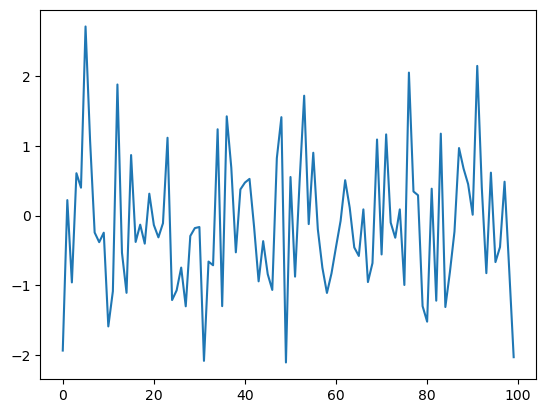

In [18]:
ts_length = 100
ϵ_values = []
i = 0
while i < ts_length:
    e = rng.standard_normal()
    ϵ_values.append(e)
    i = i + 1
plt.plot(ϵ_values)
plt.show()

Condition (```i < ts_length```) satisfy ആകുന്നത് വരെ, indentation-ൽ delimit ചെയ്ത code block ഒരു while loop execute ചെയ്ത് കൊണ്ടേയിരിക്കും.

ഈ case-ൽ, ```i``` ```ts_length```-ന് equal ആകുന്നത് വരെ program ```ϵ_values``` list-ലേക്ക് values add ചെയ്ത് കൊണ്ടേയിരിക്കും:

In [19]:
i == ts_length #the ending condition for the while loop

True

ശ്രദ്ധിക്കുക,

* `while` loop-ന്റെ code block ഇവിടെയും indentation-ൽ മാത്രമേ delimit ചെയ്യപ്പെടുന്നുള്ളൂ.
* `i = i + 1` എന്ന statement `i += 1` എന്ന് replace ചെയ്യാം.

## Another Application

Exercises-ലേക്ക് പോകുന്നതിന് മുമ്പ് ഒരു application കൂടി ചെയ്യാം.

ഈ application-ൽ, നമ്മൾ ഒരു bank account-ന്റെ balance കാലക്രമേണ plot ചെയ്യുന്നു.

$T$ എന്ന് denote ചെയ്യുന്ന last date വരെയുള്ള time period-ൽ withdraws ഒന്നും ഇല്ല.

Initial balance $b_0$ ആണ്, interest rate $r$ ആണ്.

Balance, period $t$-ൽ നിന്ന് $t+1$-ലേക്ക് $b_{t+1} = (1 + r) b_t$ എന്ന formula അനുസരിച്ച് update ആകുന്നു.

താഴെയുള്ള code-ൽ, നമ്മൾ $b_0, b_1, \ldots, b_T$ sequence generate ചെയ്ത് plot ചെയ്യുന്നു.

ഈ sequence store ചെയ്യാൻ ഒരു Python list ഉപയോഗിക്കുന്നതിന് പകരം, നമ്മൾ ഒരു NumPy
array ഉപയോഗിക്കും.

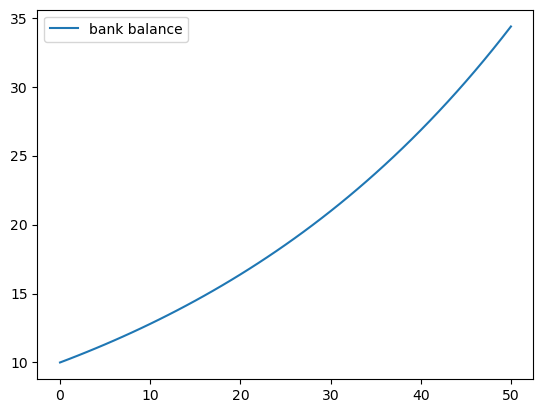

In [20]:
r = 0.025         # interest rate
T = 50            # end date
b = np.empty(T+1) # an empty NumPy array, to store all b_t
b[0] = 10         # initial balance

for t in range(T):
    b[t+1] = (1 + r) * b[t]

plt.plot(b, label='bank balance')
plt.legend()
plt.show()

`b = np.empty(T+1)` എന്ന statement `T+1`
(floating point) numbers-ന് memory-ൽ storage allocate ചെയ്യുന്നു.

ഈ numbers `for` loop വഴി fill ചെയ്യപ്പെടുന്നു.

തുടക്കത്തിൽ memory allocate ചെയ്യുന്നത്, Python list-ഉം
`append`-ഉം ഉപയോഗിക്കുന്നതിനേക്കാൾ efficient ആണ്, കാരണം അവസാനത്തേത് operating system-ൽ നിന്ന് ആവർത്തിച്ച് storage space ചോദിക്കേണ്ടി വരും.

Plot-ലേക്ക് ഒരു legend add ചെയ്തത് ശ്രദ്ധിക്കുക --- Exercises-ൽ നിങ്ങൾ
ഉപയോഗിക്കാൻ ആവശ്യപ്പെടുന്ന ഒരു feature ആണ് ഇത്.

## Exercises

ഇനി നമ്മൾ exercises-ലേക്ക് പോകുന്നു. ഇവ complete ചെയ്യുന്നത് പ്രധാനമാണ്
തുടരുന്നതിന് മുമ്പ്, കാരണം ഇവ നമുക്ക് ആവശ്യമായ പുതിയ concepts present ചെയ്യുന്നു.

```{exercise-start}
:label: pbe_ex1
```

നിങ്ങളുടെ ആദ്യ task, correlated ആയ ഈ time series simulate ചെയ്ത് plot ചെയ്യുക എന്നതാണ്

$$
x_{t+1} = \alpha \, x_t + \epsilon_{t+1}
\quad \text{where} \quad
x_0 = 0
\quad \text{and} \quad t = 0,\ldots,T
$$

Shocks-ന്റെ sequence $\{\epsilon_t\}$ IID-ഉം standard normal-ഉം ആണ് എന്ന് assume ചെയ്യുന്നു.

നിങ്ങളുടെ solution-ൽ, import statements ഇത്രമാത്രം restrict ചെയ്യുക

In [21]:
import numpy as np
import matplotlib.pyplot as plt

$T=200$-ഉം $\alpha = 0.9$-ഉം set ചെയ്യുക.

```{exercise-end}
```

```{solution-start} pbe_ex1
:class: dropdown
```

ഒരു solution ഇവിടെ.

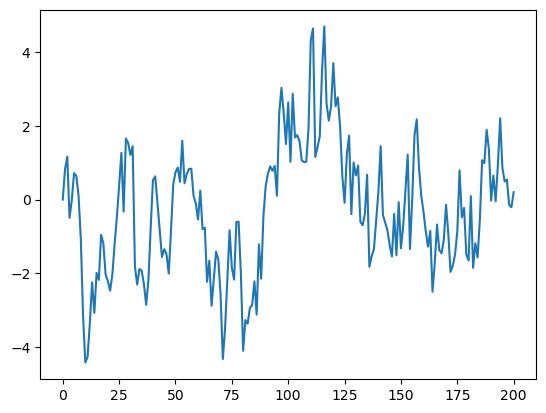

In [22]:
α = 0.9
T = 200
x = np.empty(T+1)
x[0] = 0
rng = np.random.default_rng()

for t in range(T):
    x[t+1] = α * x[t] + rng.standard_normal()

plt.plot(x)
plt.show()

```{solution-end}
```


```{exercise-start}
:label: pbe_ex2

Exercise 1-ലേക്കുള്ള നിങ്ങളുടെ solution ആരംഭ point ആയി എടുത്ത്, $\alpha=0$, $\alpha=0.8$, $\alpha=0.98$ എന്നീ ഓരോ cases-നും ഓരോന്ന്, മൂന്ന് simulated time series plot ചെയ്യുക.

$\alpha$ values-ലൂടെ step ചെയ്യാൻ ഒരു `for` loop ഉപയോഗിക്കുക.

സാധിക്കുമെങ്കിൽ, മൂന്ന് time series-നെ വേർതിരിക്കാൻ സഹായിക്കുന്ന ഒരു legend add ചെയ്യുക.

```{hint}
:class: dropdown

* `show()` call ചെയ്യുന്നതിന് മുമ്പ് `plot()` function multiple times call ചെയ്താൽ, നിങ്ങൾ produce ചെയ്യുന്ന എല്ലാ lines-ഉം ഒരേ figure-ൽ end ആകും.
* Legend-ന് വേണ്ടി, `var = 42` എന്ന് suppose ചെയ്താൽ, `f'foo{var}'` എന്ന expression `'foo42'` എന്ന് evaluate ചെയ്യുന്നു എന്ന് ശ്രദ്ധിക്കുക.
```

```{exercise-end}
```


```{solution-start} pbe_ex2
:class: dropdown
```

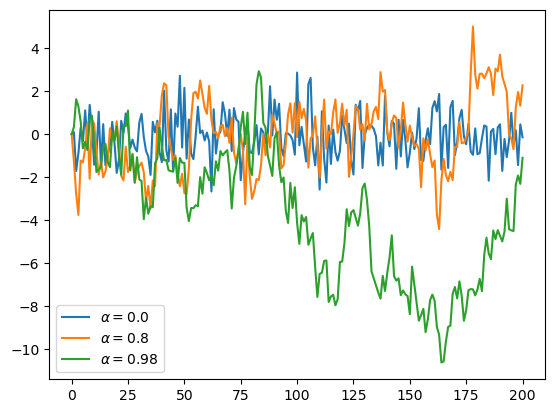

In [23]:
α_values = [0.0, 0.8, 0.98]
T = 200
x = np.empty(T+1)
rng = np.random.default_rng()

for α in α_values:
    x[0] = 0
    for t in range(T):
        x[t+1] = α * x[t] + rng.standard_normal()
    plt.plot(x, label=f'$\\alpha = {α}$')

plt.legend()
plt.show()

```{note}
Solution-ലെ `f'$\\alpha = {α}$'` എന്നത് [f-String](https://docs.python.org/3/tutorial/inputoutput.html#tut-f-strings)-ന്റെ ഒരു application ആണ്, ഇത് `{}` ഉപയോഗിച്ച് ഒരു expression contain ചെയ്യാൻ അനുവദിക്കുന്നു.

Contain ചെയ്ത expression evaluate ചെയ്യപ്പെടും, result string-ലേക്ക് place ചെയ്യപ്പെടും.
```

```{solution-end}
```

```{exercise-start}
:label: pbe_ex3

മുൻ exercises-ന് സമാനമായി, ഈ time series plot ചെയ്യുക

$$
x_{t+1} = \alpha \, |x_t| + \epsilon_{t+1}
\quad \text{where} \quad
x_0 = 0
\quad \text{and} \quad t = 0,\ldots,T
$$

$T=200$, $\alpha = 0.9$, മുമ്പത്തെ പോലെ $\{\epsilon_t\}$ ഉപയോഗിക്കുക.

Absolute value $|x_t|$ compute ചെയ്യാൻ ഉപയോഗിക്കാവുന്ന ഒരു function online search ചെയ്യുക.
```

```{exercise-end}
```


```{solution-start} pbe_ex3
:class: dropdown
```

ഒരു solution ഇവിടെ:

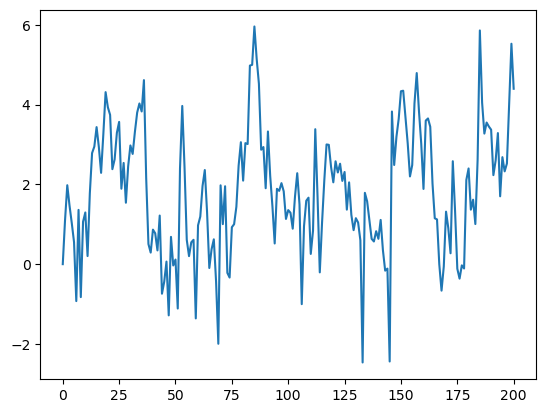

In [24]:
α = 0.9
T = 200
x = np.empty(T+1)
x[0] = 0
rng = np.random.default_rng()

for t in range(T):
    x[t+1] = α * np.abs(x[t]) + rng.standard_normal()

plt.plot(x)
plt.show()

```{solution-end}
```


```{exercise-start}
:label: pbe_ex4
```

മിക്കവാറും എല്ലാ programming languages-ന്റെയും ഒരു പ്രധാന aspect branching-ഉം
conditions-ഉം ആണ്.

Python-ൽ, conditions സാധാരണയായി if--else syntax ഉപയോഗിച്ചാണ് implement ചെയ്യുന്നത്.

ഇവിടെ ഒരു example, ഒരു array-ലെ ഓരോ negative number-നും -1-ഉം, ഓരോ nonnegative number-നും 1-ഉം
print ചെയ്യുന്നു

In [25]:
numbers = [-9, 2.3, -11, 0]

In [26]:
for x in numbers:
    if x < 0:
        print(-1)
    else:
        print(1)

-1
1
-1
1


ഇപ്പോൾ, absolute value compute ചെയ്യാൻ ഒരു existing function ഉപയോഗിക്കാതെ Exercise 3-ന് ഒരു
പുതിയ solution എഴുതുക.

ഈ existing function-ന് പകരം ഒരു if--else condition ഉപയോഗിക്കുക.

```{exercise-end}
```

```{solution-start} pbe_ex4
:class: dropdown
```

ഒരു വഴി ഇവിടെ:

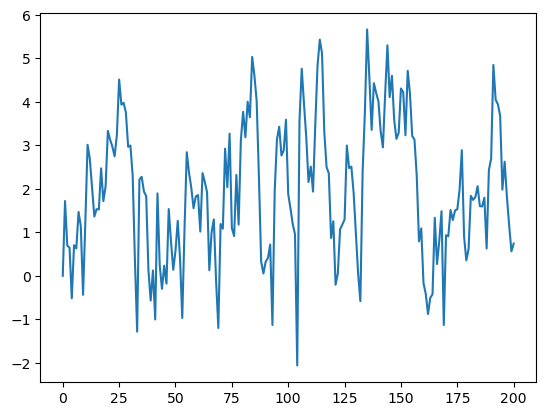

In [27]:
α = 0.9
T = 200
x = np.empty(T+1)
x[0] = 0
rng = np.random.default_rng()

for t in range(T):
    if x[t] < 0:
        abs_x = - x[t]
    else:
        abs_x = x[t]
    x[t+1] = α * abs_x + rng.standard_normal()

plt.plot(x)
plt.show()

ഇത് തന്നെ എഴുതാൻ ഒരു shorter വഴി:

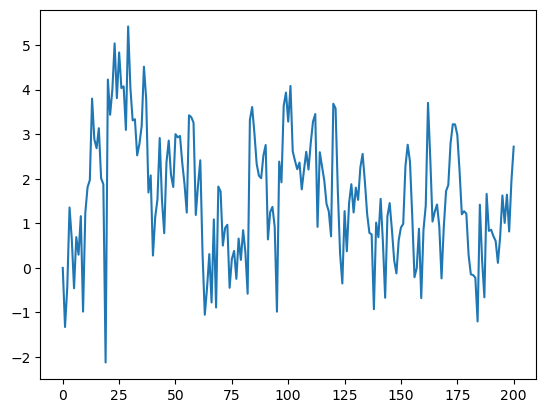

In [28]:
α = 0.9
T = 200
x = np.empty(T+1)
x[0] = 0
rng = np.random.default_rng()

for t in range(T):
    abs_x = - x[t] if x[t] < 0 else x[t]
    x[t+1] = α * abs_x + rng.standard_normal()

plt.plot(x)
plt.show()

```{solution-end}
```



```{exercise-start}
:label: pbe_ex5
```

ഇവിടെ കുറച്ച് thought-ഉം planning-ഉം ആവശ്യമുള്ള ഒരു harder exercise ഉണ്ട്.

[Monte Carlo](https://en.wikipedia.org/wiki/Monte_Carlo_method) ഉപയോഗിച്ച് $\pi$-ന്റെ ഒരു approximation compute ചെയ്യുക എന്നതാണ് task.

ഇത് കൂടാതെ മറ്റൊന്നും import ചെയ്യരുത്

In [29]:
import numpy as np

```{hint}
:class: dropdown

നിങ്ങളുടെ hints ഇവയാണ്:

* $U$ എന്നത് unit square $(0, 1)^2$-ലെ ഒരു bivariate uniform random variable ആണെങ്കിൽ, $U$, $(0,1)^2$-ന്റെ ഒരു subset $B$-ൽ വീഴാനുള്ള probability $B$-യുടെ area-ന് equal ആണ്.
* $U_1,\ldots,U_n$ എന്നത് $U$-യുടെ IID copies ആണെങ്കിൽ, $n$ വലുതാകുന്നതിനനുസരിച്ച്, $B$-ൽ വീഴുന്ന fraction, $B$-യിൽ വീഴാനുള്ള probability-ലേക്ക് converge ചെയ്യുന്നു.
* ഒരു circle-ന്, $area = \pi * radius^2$.
```

```{exercise-end}
```


```{solution-start} pbe_ex5
:class: dropdown
```

Unit square-ൽ embed ചെയ്ത diameter 1 ഉള്ള circle കരുതുക.

$A$ അതിന്റെ area ആണെന്നും $r=1/2$ അതിന്റെ radius ആണെന്നും കരുതുക.

$\pi$ അറിയാമെങ്കിൽ, $A$
$A = \pi r^2$ വഴി compute ചെയ്യാം.

എന്നാൽ ഇവിടെ point $\pi$ compute ചെയ്യുക എന്നതാണ്, ഇത് നമുക്ക്
$\pi = A / r^2$ വഴി ചെയ്യാം.

Summary: Diameter 1 ഉള്ള ഒരു circle-ന്റെ area estimate ചെയ്യാൻ കഴിഞ്ഞാൽ, $r^2 = (1/2)^2 = 1/4$ കൊണ്ട്
divide ചെയ്യുന്നത് $\pi$-ന്റെ ഒരു estimate നൽകുന്നു.

Bivariate uniforms sample ചെയ്ത്, circle-ൽ വീഴുന്ന
fraction നോക്കി നമ്മൾ area estimate ചെയ്യുന്നു.

In [30]:
n = 1000000 # sample size for Monte Carlo simulation
rng = np.random.default_rng()

count = 0
for i in range(n):

    # drawing random positions on the square
    u, v = rng.uniform(), rng.uniform()

    # check whether the point falls within the boundary
    # of the unit circle centred at (0.5,0.5)
    d = np.sqrt((u - 0.5)**2 + (v - 0.5)**2)

    # if it falls within the inscribed circle, 
    # add it to the count
    if d < 0.5:
        count += 1

area_estimate = count / n

print(area_estimate * 4)  # dividing by radius**2

3.14326


```{solution-end}
```